# Figure 4: panels l to o

In order to run this notebook, you should download the Anipose project: 
- `202505-revision-chew-rig2`

You should also have a local copy of the .csv files in the following behavior sessions (fe-data folder):
- `20250514_B38-B39-B41-B55-B60-B61_chewing_rig2`
- `20250515_B38-B55-B60-B61_chewing_rig2`
- `20250516_B38-B55-B60-B61_chewing_rig2`
- `20250517_B38-B55-B60-B61_chewing_rig2`
- `20250518_B38-B55-B60-B61_chewing_rig2`
- `20250621_B54-B56-B58_chewing_rig2`
- `20250622_B54-B56-B58_chewing_rig2`
- `20250623_B54-B56-B58_chewing_rig2`
- `20250624_B54-B56-B58_chewing_rig2`
- `20250625_B58_chewing_rig2`

And experiment information about all mice and sessions:
- `Pellet_table_revision.csv`

To run fast the notebook, consider downloading the facial features timeseries directly:
- `afterB38correct-review-chew-meas.pkl`

In [1]:
%load_ext autoreload
%autoreload 2

# Update path as if notebook was run from top-level repo directory
import os
import sys
pwd = %pwd
if not pwd.endswith('mouse-fe-analysis'):
    sys.path.insert(0, os.path.abspath('..'))
    new_pwd = os.path.abspath(f"{pwd}/..")
    %cd {new_pwd}

/data/disk2/irenenozal/mouse-fe-analysis


/home/irenenozal/micromamba/envs/mouse-fe-analysis/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import numpy as np
import scipy as sp
from scipy.signal import find_peaks
from scipy.stats import (linregress, wilcoxon)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import kneed
from functools import partial

from fepipeline.anatomy import (compute_mouth_area,
                                compute_nose_bulge_volume,
                                compute_cheek_bulge_volume,
                                compute_proptosis,
                                compute_ear_angle,
                                compute_eye_orbital_tightness,
                                compute_angle)
from fepipeline.features.landmarks import read_3d_data

from labutils.plotting import (sns_setup,
                               save_figure,
                               landmark_cmap,
                               measurements_cmap)

import warnings
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

# set seaborn theme
sns_setup("paper")
OUTPUT_DIR = "./figures/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# get cluster cmaps
LANDMARKS_CLUSTERS, LANDMARK_CMAP = landmark_cmap()
MEASUREMENT_CLUSTERS, MEASUREMENT_CMAP = measurements_cmap()

CONTROL_CMAP = sns.color_palette([sns.color_palette("colorblind")[2],
                                  sns.color_palette("colorblind")[-3],
                                  sns.color_palette("colorblind")[3]])

## Functions

In [3]:
# Correct notorius artifact in this session of B38
# See where this function is called for implementation
def fix_B38(trace, window = 10):
    peak_artifact = np.where(trace == np.max(trace))[0][0] #Find outstanding artifact
    artifacts = np.arange(peak_artifact - window//2, peak_artifact + window//2)
    trace[artifacts] = np.nan
    nans = np.isnan(trace) #For expected behavior - assumes there is no artifacts other than the incorporated above
    if np.any(nans):
        t = np.arange(len(trace))
        trace[nans] = np.interp(t[nans], t[~nans], trace[~nans])

    return trace

# Example
# trace = meas_df.query("date == '20250518' & mouse == 'B38' & measurement_name == 'mouth-area'")["raw_timeseries"].values[0]
# print(np.max(trace))
# test = fix_B38(trace)
# print(np.max(test))


In [4]:
def sanitize_signal(row, window = 10):
    # Populate this function with your favorite artifact detection/correction code if needed
    # See 2025-05-20-ephys-recording.ipynb notebook for an example
    signal = row["raw_timeseries"]
    if row["mouse"] == 'B38' and row["date"] == '20250518': # modified August 22nd, 2025 to correct B38 day4 big artifact only
        return fix_B38(signal)
    else:
        return signal

## Load data

Load 3D coordinates for all mice and sessions

In [5]:
from pathlib import Path

# ANIPOSE_DIR = "./anipose-projects/omnibus-splitsession-20231031_B6-B20-B21-B26-B31-B32-B33_chew_rig2"
ANIPOSE_DIR = "./anipose-projects/202505-revision-chew-rig2"
MICE = ["B38", "B55", "B60", "B61", "B54", "B56", "B58"]
BASE_DIRS = {}
COORDINATE_PATHS = {}
for s in os.listdir("./anipose-projects/202505-revision-chew-rig2"):     
    if "config" not in s and "score" not in s:
        nparts = s.split("_")
        date = nparts[0]
        mouse = nparts[1]
        cond = nparts[3]
        BASE_DIRS[date, mouse, cond] = os.sep.join([ANIPOSE_DIR, s])
        COORDINATE_PATHS[date, mouse, cond] = [p for p in Path(BASE_DIRS[date, mouse, cond]).glob('pose-3d/*.csv')][0]

# The coord_data below is a dictionary of tuples (each key is a mouse-date-condition), 
#   - the 1st term of the tuple is a dictionary where keys are keypoints 
#     and values are a 3xN array with the xyz coordinates for the length of the recording
#   - the 2nd term is a dictionary with 2 keys (extra_cols) and the values 
#     are dictionaries with all keypoints and respective ncam/score value per timepoint
coord_data = {k: read_3d_data(v.parent.parent.as_posix(),
                              extra_cols=["ncams", "score"])
              for k, v in COORDINATE_PATHS.items()}
data_keys = [dmc for dmc in sorted(coord_data.keys(), key=lambda x: (x[1], x[0]))
             if "pilot" not in dmc]
data_keys


[('20250514', 'B38', 'day0'),
 ('20250515', 'B38', 'day1'),
 ('20250516', 'B38', 'day2'),
 ('20250517', 'B38', 'day3'),
 ('20250518', 'B38', 'day4'),
 ('20250621', 'B54', 'day0'),
 ('20250622', 'B54', 'day1'),
 ('20250623', 'B54', 'day2'),
 ('20250624', 'B54', 'day3'),
 ('20250514', 'B55', 'day0'),
 ('20250515', 'B55', 'day1'),
 ('20250516', 'B55', 'day2'),
 ('20250517', 'B55', 'day3'),
 ('20250621', 'B56', 'day0'),
 ('20250622', 'B56', 'day1'),
 ('20250623', 'B56', 'day2'),
 ('20250624', 'B56', 'day3'),
 ('20250621', 'B58', 'day0'),
 ('20250622', 'B58', 'day1'),
 ('20250623', 'B58', 'day2'),
 ('20250624', 'B58', 'day3'),
 ('20250625', 'B58', 'day4'),
 ('20250515', 'B60', 'day1'),
 ('20250516', 'B60', 'day2'),
 ('20250517', 'B60', 'day3'),
 ('20250518', 'B60', 'day4'),
 ('20250515', 'B61', 'day1'),
 ('20250516', 'B61', 'day2'),
 ('20250517', 'B61', 'day3'),
 ('20250518', 'B61', 'day4')]

Load all behavior .csv files (with experiment timestamps)

In [6]:
import pandas as pd

FEDATA_DIRS = ["./fe-data/20250514_B38-B39-B41-B55-B60-B61_chewing_rig2",
              "./fe-data/20250515_B38-B55-B60-B61_chewing_rig2",
              "./fe-data/20250516_B38-B55-B60-B61_chewing_rig2",
              "./fe-data/20250517_B38-B55-B60-B61_chewing_rig2",
              "./fe-data/20250518_B38-B55-B60-B61_chewing_rig2",
              "./fe-data/20250621_B54-B56-B58_chewing_rig2",
              "./fe-data/20250622_B54-B56-B58_chewing_rig2",
              "./fe-data/20250623_B54-B56-B58_chewing_rig2",
              "./fe-data/20250624_B54-B56-B58_chewing_rig2",
              "./fe-data/20250625_B58_chewing_rig2"
              ]
ITI = 30 # inter-trial interval, in seconds
FPS = 100 # frames per second

timestamps = {}
for dir in FEDATA_DIRS:
    for f in os.listdir(dir):
        if 'csv' in f and '_cal_' not in f:
            date = f.split("_")[0]
            mouse = f.split("_")[1]
            cond = f.split("_")[3]
            ts_col = pd.read_csv(os.sep.join([dir, f]), header=None)[12].values
            timestamps[date, mouse, cond] = np.append("O", ts_col[1:]) #avoid weird string at idx 0 in some cases


Load the success/fail/repeated trials and 0/5 seconds regime in `pellet_table`.

In [7]:
TRIAL_IDX_DIR = "./trialized_data"

pellet_table = pd.read_csv(os.sep.join([TRIAL_IDX_DIR, "Pellet_table_revision.csv"]))

# These are the trials when the spoon was in front of the mouse's mouth for 5 seconds
regime_5sec = {("20250514", "B38", "day0"): np.arange(1, 50), #This session ended 1 trial early (remember np.arange(1,3) = [1, 2])
               ("20250515", "B38", "day1"): np.arange(1, 23),
               ("20250516", "B38", "day2"): [],
               ("20250517", "B38", "day3"): [],
               ("20250518", "B38", "day4"): [],
               ("20250514", "B55", "day0"): np.arange(1, 32),
               ("20250515", "B55", "day1"): np.concatenate([np.arange(1, 7), np.arange(36, 51)]),
               ("20250516", "B55", "day2"): [],
               ("20250517", "B55", "day3"): [],
               ("20250515", "B60", "day1"): np.arange(1, 51),
               ("20250516", "B60", "day2"): np.arange(1, 14),
               ("20250517", "B60", "day3"): np.arange(11, 51),
               ("20250518", "B60", "day4"): [],
               ("20250515", "B61", "day1"): [],
               ("20250516", "B61", "day2"): [],
               ("20250517", "B61", "day3"): [],
               ("20250518", "B61", "day4"): [],
               ("20250621", "B54", "day0"): [],
               ("20250622", "B54", "day1"): [],
               ("20250623", "B54", "day2"): [],
               ("20250624", "B54", "day3"): [],
               ("20250621", "B56", "day0"): [],
               ("20250622", "B56", "day1"): [],
               ("20250623", "B56", "day2"): [],
               ("20250624", "B56", "day3"): [],
               ("20250621", "B58", "day0"): np.arange(1, 51),
               ("20250622", "B58", "day1"): np.arange(1, 44),
               ("20250623", "B58", "day2"): [],
               ("20250624", "B58", "day3"): [],
               ("20250625", "B58", "day4"): []
          }


Define trial indeces.

In [8]:
import pickle

def letter_rising_edge(ts, letter):
    all_idx = np.where(ts == letter)[0]
    last_idx = 0
    rises_idx = []
    for idx in all_idx:
        if (idx > last_idx + 10 * FPS) and (idx + ITI*FPS) < len(vals): # At least 10 s away &  Exception for B38, day0 (exp ended early)
            rises_idx.append(idx)
            last_idx = idx
    
    return rises_idx

base_trials = {}
trial_states = {}
STATES = ["D", "E", "R", "F"] ##{'D' - deploy, 'E' - max extension, 'R' - retract, 'F' - food pellet, 'O' - no action}
OFFSET = 5 * FPS # in samples (time before t0)

for k, vals in timestamps.items():
    trial_states[k] = {ltr: letter_rising_edge(vals, ltr) for ltr in STATES}
    base_trials[k] = np.array([np.arange(idx - OFFSET, idx + ITI*FPS) for idx in trial_states[k]['D']])

Trialize data.

In [9]:
# Trialize the data
landmarks_data = {mouse: {landmark: coords[base_trials[mouse], :]
                             for landmark, coords in data[0].items()}
                     for mouse, data in coord_data.items() if "pilot" not in mouse}

ntrials = {mouse: len(base_trials[mouse]) for mouse in landmarks_data.keys()}

Compute (or load) facial features:

In [10]:
from fepipeline.anatomy import compute_measurements_df
DATA_CACHE = "measurements-data-cache"
MEAS_DATA_CACHE = os.sep.join([DATA_CACHE, "afterB38correct-review-chew-meas.pkl"])

key_cols = ("date", "mouse", "condition")


if os.path.exists(MEAS_DATA_CACHE):
    meas_df = pd.read_pickle(MEAS_DATA_CACHE)
else:
    meas_df = compute_measurements_df({k: v[0] for k, v in coord_data.items()},
                                    key_columns=key_cols)
    pd.to_pickle(meas_df, MEAS_DATA_CACHE)

meas_df = meas_df.rename(columns={"timeseries": "raw_timeseries"})
meas_df["timeseries"] = meas_df.apply(sanitize_signal, axis=1) # Not used besides B38
meas_df.head(3)

,date,mouse,condition,measurement_group,measurement_name,measurement_units,measurement_type,measurement_value,std,count,raw_timeseries,timeseries
407,20250515,B38,day1,cheek,cheek-bulge-volume,mm^3,volume,48.735689,2.484887,165525,"[48.46746801388363, 47.86698028526802, 48.0572...","[48.46746801388363, 47.86698028526802, 48.0572..."
516,20250514,B38,day0,ear,ear-height-left,mm,distance,12.745441,0.505649,155641,"[11.538569682341619, 11.351717172689742, 11.30...","[11.538569682341619, 11.351717172689742, 11.30..."
515,20250514,B38,day0,eye,eye-area-right,mm^2,area,8.837909,0.558242,155641,"[8.980762270004117, 8.978781586370742, 8.90721...","[8.980762270004117, 8.978781586370742, 8.90721..."


Define sessions that can be used to study potential satiation-related behavior. Mainly, I excluded sessions with trials/pellets eaten in the 5-second regime.

`satiation_study` is a dictionary with such sessions as keys, and the values are the relative weight with respect to the non-fasted weight at the beginning of each session.

In [11]:
satiation_study = {('20250516', 'B38', 'day2'): 89.5,
                    ('20250517', 'B38', 'day3'): 91.6,
                    ('20250518', 'B38', 'day4'): 88.9,
                    ('20250621', 'B54', 'day0'): 86.7,
                    ('20250622', 'B54', 'day1'): 87.1,
                    ('20250623', 'B54', 'day2'): 88.1,
                    ('20250624', 'B54', 'day3'): 86.3,
                    # ('20250515', 'B55', 'day1'): 92.9, #includes 5 sec regime part
                    ('20250516', 'B55', 'day2'): 90,
                    ('20250517', 'B55', 'day3'): 88.7,
                    ('20250621', 'B56', 'day0'): 85.7,
                    ('20250622', 'B56', 'day1'): 88.0,
                    ('20250623', 'B56', 'day2'): 89.1,
                    ('20250624', 'B56', 'day3'): 86.1,
                    ('20250623', 'B58', 'day2'): 85.9,
                    ('20250624', 'B58', 'day3'): 85.0,
                    ('20250625', 'B58', 'day4'): 85.2,
                    ('20250518', 'B60', 'day4'): 88.1,
                    ('20250515', 'B61', 'day1'): 89.9,
                    ('20250516', 'B61', 'day2'): 89.2,
                    ('20250517', 'B61', 'day3'): 88.6,
                    ('20250518', 'B61', 'day4'): 87.9
                    }

## Panel l

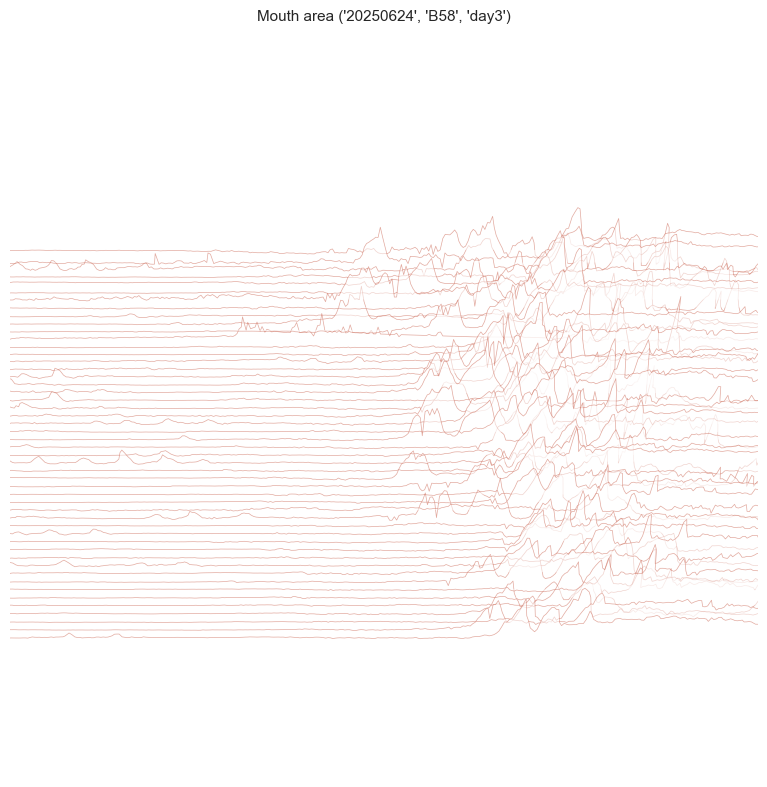

In [12]:
import matplotlib.collections as mc
from mpl_toolkits.mplot3d import Axes3D

example_dmc = ('20250624', 'B58', 'day3')

mouth_example = meas_df.query("date == @example_dmc[0] & "
                                  "mouse == @example_dmc[1] & "
                                  "condition == @example_dmc[2] & "
                                  "measurement_name == 'mouth-area'")["raw_timeseries"].values[0]
    
# Define the number of traces and data points per trace
total_trials = len(base_trials[example_dmc]) #50 # Number of trials
n_timepoints = len(base_trials[example_dmc][0])  # Number of data points
time_range = np.linspace(-OFFSET/100, ITI, n_timepoints) # Time

n_trials = base_trials[example_dmc] # trials timeseries
trial_count = 0

# Create the 3D-like plot using PolyCollection
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create polygons for each trial
polygons = []
colors = []
zs = []

for i, trial in enumerate(n_trials): #iterate over trials
    date = int(example_dmc[0])
    success = pellet_table.query("Date == @date & "
                                "Mouse == @example_dmc[1] & "
                                "Cond == @example_dmc[2]")[f"Pellet {i + 1}"].values[0]
    # Get the data for this trial
    if success != -1: # Do not plot repeated trials
        area = mouth_example[trial] #mouth_example[f"Trial {i}"][0]
        
        # Define vertices for the polygon (time vs mouth area amplitude)
        vertices = [] 
        
        # Add all the data points
        for ts, amp in zip(time_range, area):
            vertices.append((ts, amp))
        
        
        polygons.append(vertices)
        zs.append(trial_count)
        trial_count += 1
        colors.append([1,1,1, 0.5]) #White filling with some transparency (alpha = 0.5)

# Create the PolyCollection
poly_collection = mc.PolyCollection(
    polygons,
    facecolors=colors,
    edgecolors=MEASUREMENT_CMAP["mouth-area"],
    closed = False,
    alpha=0.5,
    linewidths=0.5
)

# poly_collection

# Add the collection to the 3D plot
ax.add_collection3d(poly_collection, zs=zs[::-1], zdir='y')

# Set the limits and labels
# ax.set_xlim(-5, 30)
ax.set_xlim(0, 2) # Plot only the first 2 seconds
# ax.set_ylim(0, n_trials)
# ax.set_yticklabels(np.arange(0,51,10)[::-1])
# ax.set_zlim(0, 3.5)

ax.set_xlabel('Time (sec)')
ax.set_ylabel('Trial #')
ax.set_zlabel('Area')
ax.set_title(f'Mouth area {example_dmc}')

# Adjust the viewing angle
# ax.view_init(elev=20, azim=-135)
# ax.view_init(elev=60, azim=-90)
ax.view_init(elev=70, azim=-90)
ax.axis("off")

plt.tight_layout()
plt.show()

# save_figure()
# plt.savefig(f"rev_figs/chew/50chew/50chew-{example_dmc[1]}-{example_dmc[0]}")

## Panel m

In [13]:
# Find the first value above the `peak_thres` threshold

tgap = 5 #5 #10 #in samples
peak_thres = 3 #in area units
first_peak_dict = {}

for dmc in data_keys:
    raw_data = meas_df.query("date == @dmc[0] & mouse == @dmc[1] & condition == @dmc[2] & "
                        "measurement_name == 'mouth-area'")["raw_timeseries"].values[0]    
    trial_n = 0
    valid_trial = 0
    first_peak_dict[dmc] = []
    for trial, t_range in enumerate(base_trials[dmc]):
        raw_area = raw_data[t_range]
        area_diff = raw_area[OFFSET + tgap:] - raw_area[OFFSET:-tgap] # compute difference starting from t = 0
        date = int(dmc[0])
        spoon_retract = trial_states[dmc]['R'][trial] - base_trials[dmc][trial][0] #index of retraction within trial
        success = pellet_table.query("Date == @date & Mouse == @dmc[1] & Cond == @dmc[2]")[f"Pellet {trial + 1}"].values[0]

        if success != -1: #technical misses (no pellet on spoon)
            ts = (np.arange(0, len(raw_area)) - OFFSET) / FPS # Time in seconds
            area_peaks = np.where(area_diff > peak_thres)[0] + OFFSET #index
            if len(area_peaks) > 0:
                if area_peaks[0] <= (OFFSET + 2 * FPS): # 2 s = max time allowed for 1st peak
                    first_peak_dict[dmc].append(area_peaks[0])
                else: #If peak found outside [0, 2] sec window, default to 2
                    first_peak_dict[dmc].append(OFFSET + 2 * FPS) #max possible value
            else: #If no peak found within [0, 2] sec window, default to 2
                first_peak_dict[dmc].append(OFFSET + 2 * FPS) #max possible value
            trial_n += 1
            valid_trial += 1


Text(0.5, 0.98, 'B58')

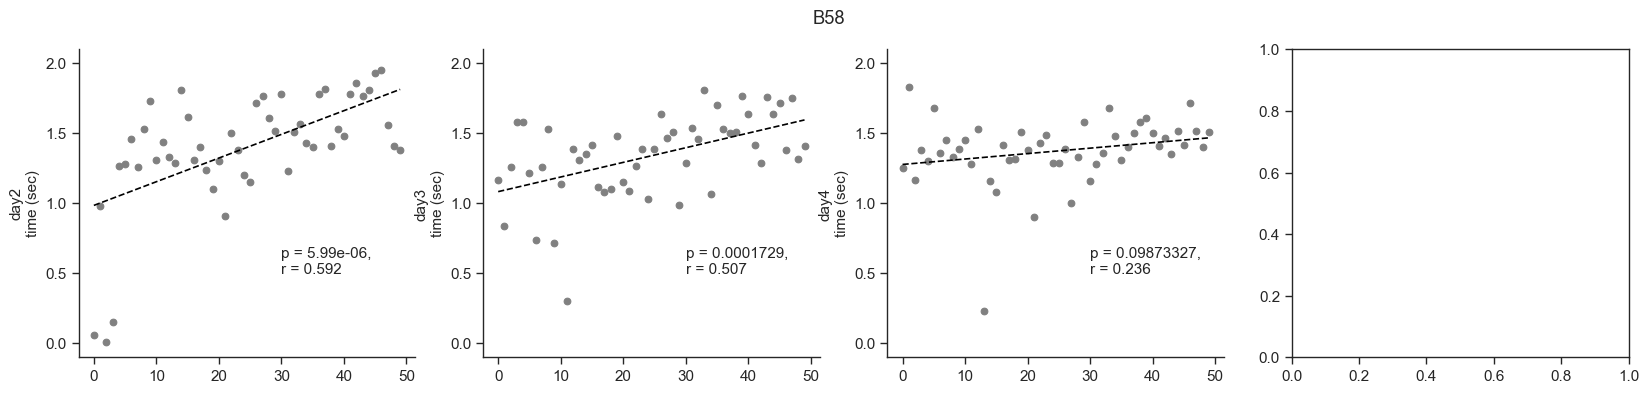

In [14]:
current_mouse = list(satiation_study.keys())[0][1]
day_total = sum(1 for _dmc in satiation_study if _dmc[1] == current_mouse)
fig, axs = plt.subplots(1, 4, figsize=(5 * 4, 4)) #4 is max n of days, this allows same dims for all mice
fig.suptitle(current_mouse)
sday = 0
m_dict = {}
n_dict = {}
lin_fits = {}

for dmc in satiation_study.keys():
    
    # Linear regression
    xs = np.arange(0, len(first_peak_dict[dmc]))
    ys = (np.array(first_peak_dict[dmc]) - OFFSET) / FPS
    m, n, r_val, p_val, std_err = linregress(xs, ys) # m = slope, n = intercept
    ysh = m * xs + n
    m_dict[dmc] = m
    n_dict[dmc] = n
    lin_fits[dmc] = ysh

    if dmc[1] == 'B58':
        axs[sday].scatter(xs, ys, color = 'gray')
        axs[sday].plot(xs, ysh, linestyle = '--', color = 'black')
        axs[sday].set(ylim = (-0.1, 2.1), ylabel = f"{dmc[2]}\ntime (sec)")
        axs[sday].yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        axs[sday].spines[['top', 'right']].set_visible(False)
        axs[sday].text(30, 0.5, f'p = {round(p_val,8) if p_val > 1e-8 else p_val},\nr = {round(r_val,3)}')
        
        sday += 1
fig.suptitle('B58')
# save_figure("rev_figs/chew/1bite/",f"1st-peak-{current_mouse}", fig, formats = ["svg"])

## Panel n

Text(-20, 18.5, 'p-value =  1.56e-02')

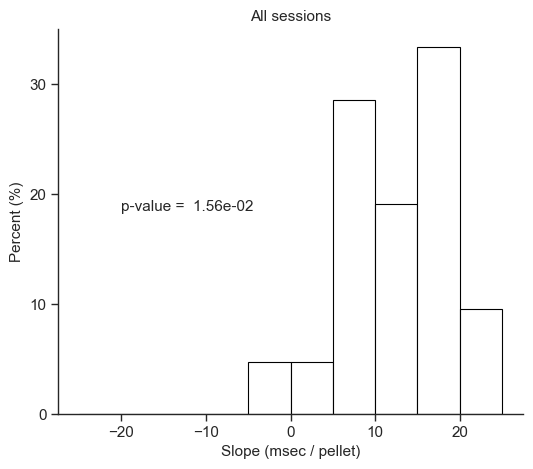

In [15]:
# Histogram of slopes of fitted lines and stats
m_mouse_mean = []
for mouse in MICE:
    m_mouse = []
    for dmc, m in m_dict.items():
        if mouse in dmc:
            m_mouse.append(m)
    m_mouse_mean.append(np.mean(m_mouse))

fig, ax = plt.subplots(1,1,figsize = (6,5))

sns.histplot(1000 * np.array(list(m_dict.values())), bins = np.arange(-25,26,5), 
             kde = False, stat = 'percent', legend = False,
             color = 'white', edgecolor = 'black')
ax.set(title = "All sessions",
       ylabel = 'Percent (%)', 
       xlabel = "Slope (msec / pellet)") #, xlim=[-0.0045,0.03])
ax.set_yticks(np.arange(0, 31, 10))
# ax.set_xticklabels(np.arange(-25, 31, 10))
# ax.set_xticklabels(np.arange(0,26,5))
sns.despine()

# Using average m per mouse 
stat, pval = wilcoxon(m_mouse_mean) #no assumption about the underlying distribution

ax.text(-20, 18.5,  'p-value = ' + f'{pval: .2e}')
# save_figure("rev_figs/chew/", "fitted-m-distribution", fig, formats = ["svg"])

## Panel o

/tmp/ipykernel_598235/92504658.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_yticklabels(np.arange(-5, 21, 5))


Text(89.5, 0.002, 'r = 0.151217\np = 0.512912')

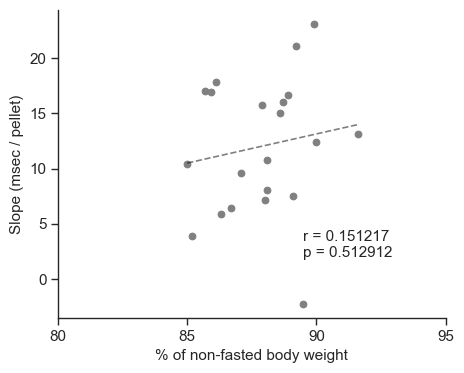

In [16]:
# Compare weight of the mouse before the experiment vs slope of the fitted line
fig, axs = plt.subplots(1,1,figsize=(5,4))
for dmc, weight in satiation_study.items():
    plt.scatter(weight, m_dict[dmc], color = 'gray')  

# Fit a line to the points
xs = np.array(list(satiation_study.values()))
m, n, r_val, p_val, std_err = linregress(xs, np.array(list(m_dict.values()))) # m = slope, n = intercept
ysh = m * xs + n
sns.lineplot(x = xs, y = ysh, color='black', alpha = 0.5, linestyle = 'dashed')

axs.set(ylabel = 'Slope (msec / pellet)', xlabel = '% of non-fasted body weight')
axs.set_xticks(np.arange(80, 96, 5))
axs.set_yticklabels(np.arange(-5, 21, 5))
axs.spines[['top', 'right']].set_visible(False)
axs.text(89.5, 0.002, f'r = {round(r_val,6)}\np = {round(p_val,6)}')
# save_figure("rev_figs/chew/", "weight-vs-fitted-m", fig, formats = ["svg"])

# Extended Data Figure 9

## Panel A

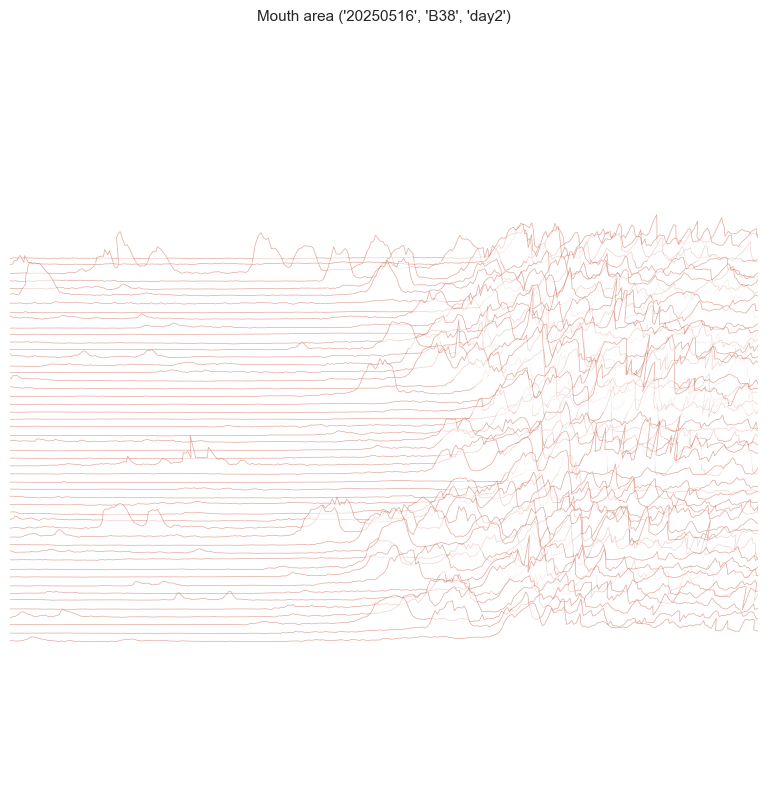

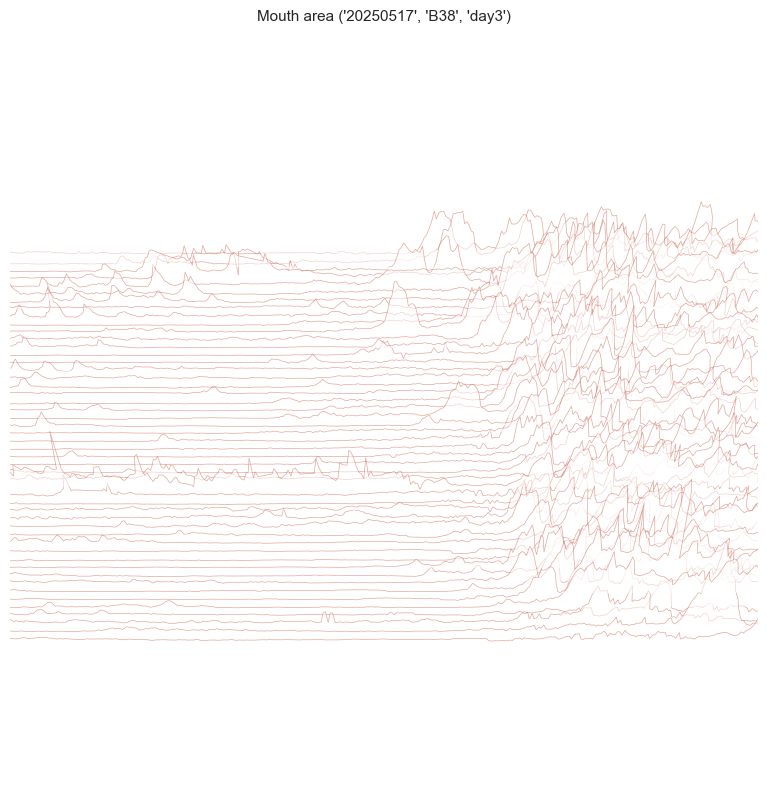

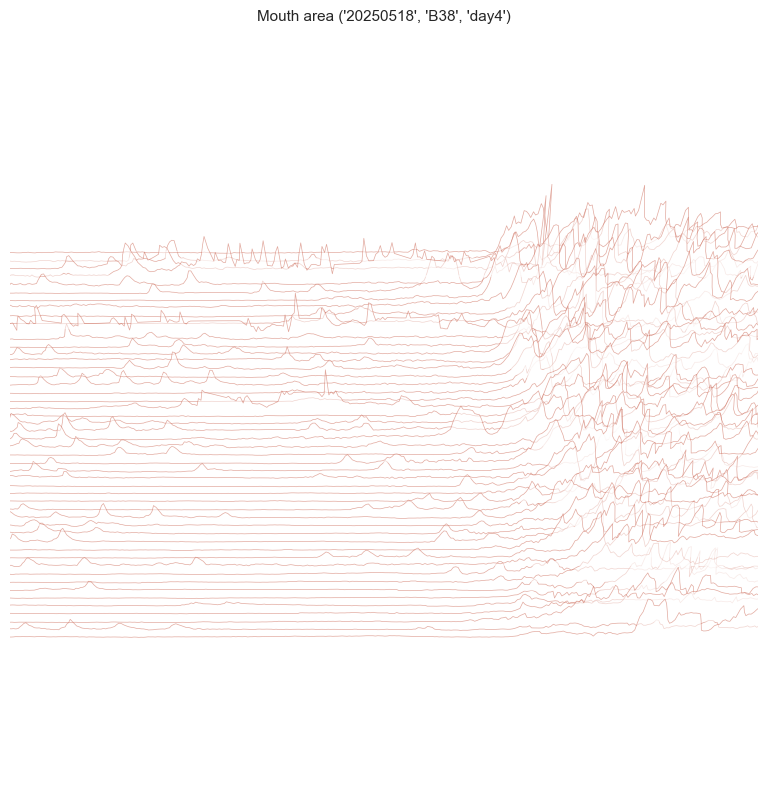

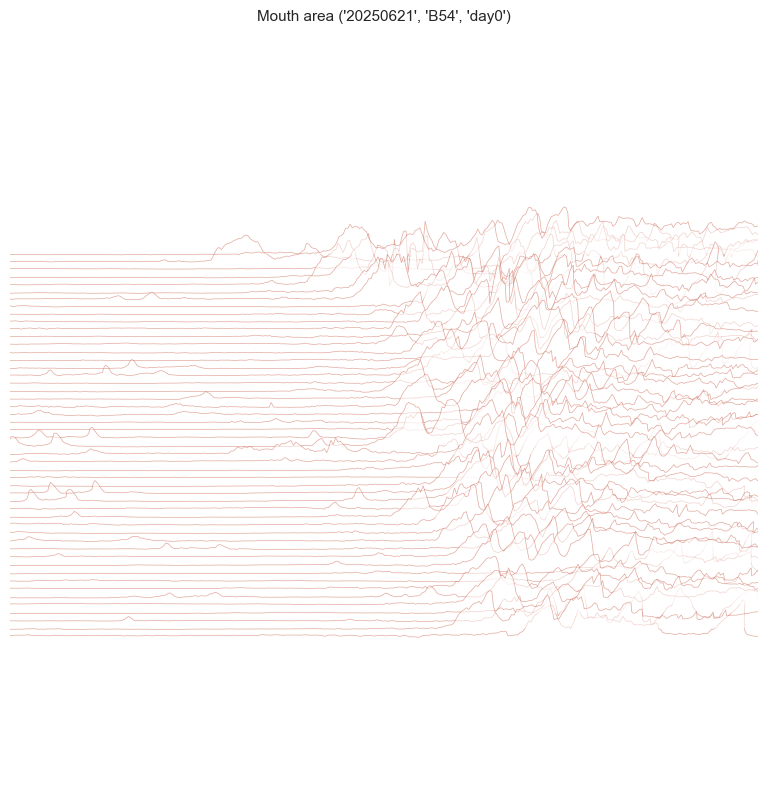

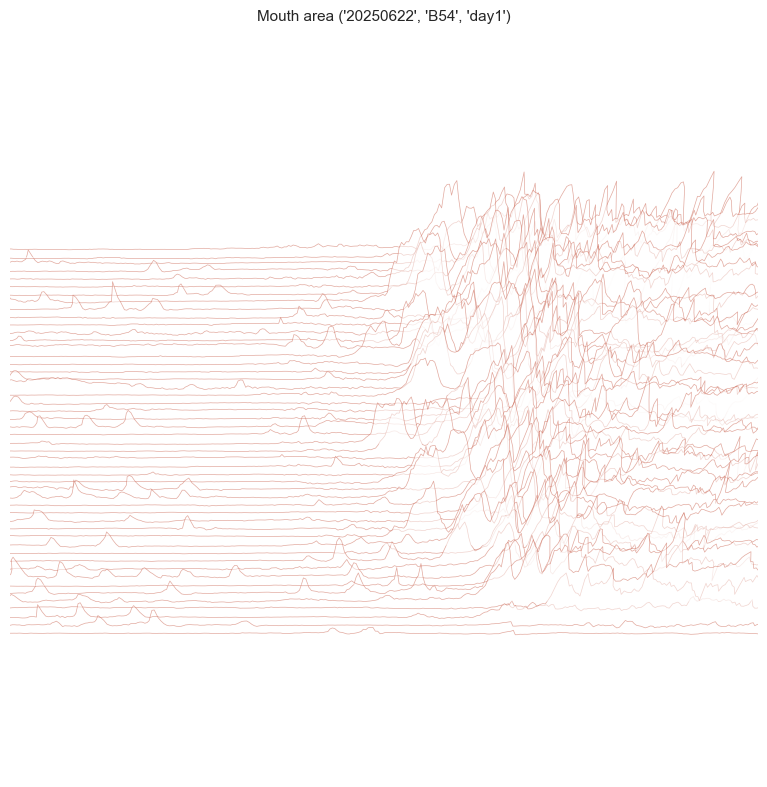

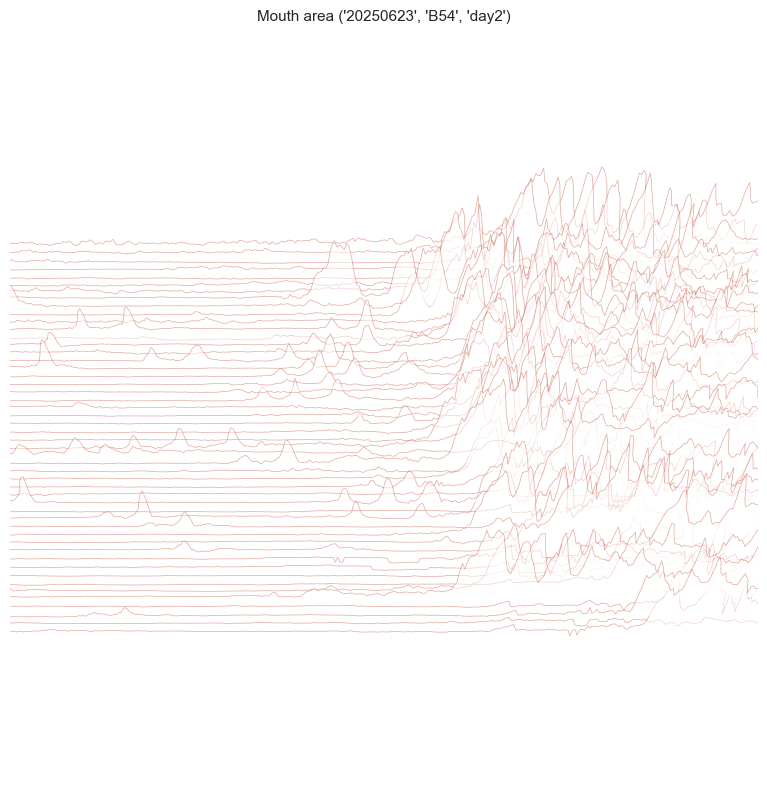

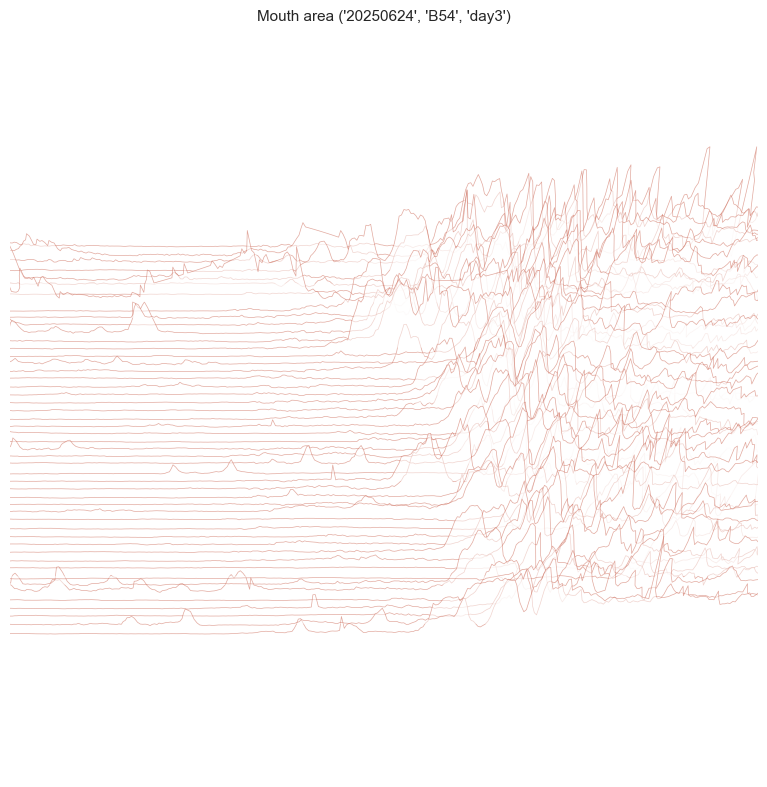

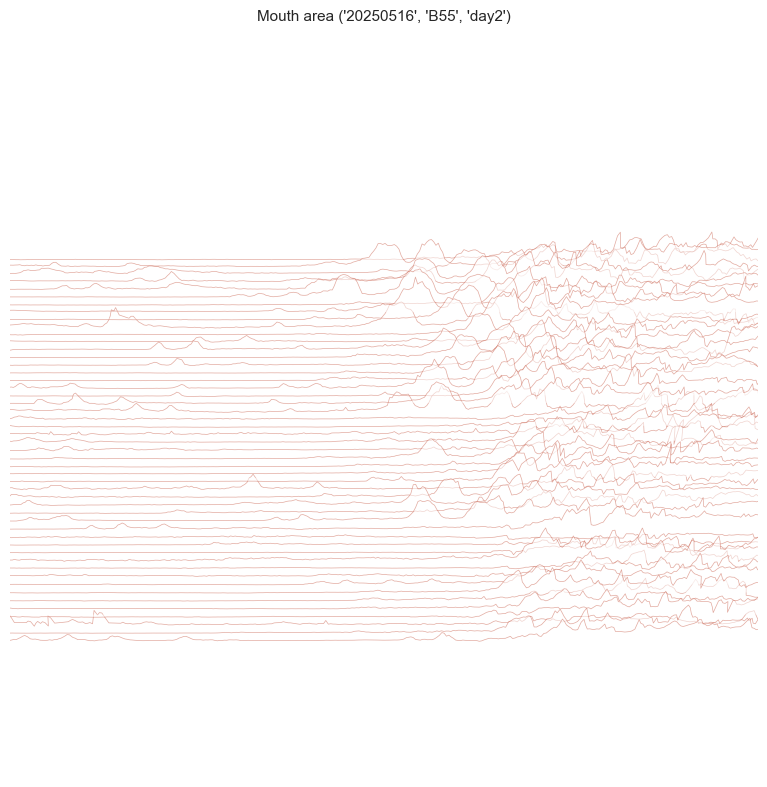

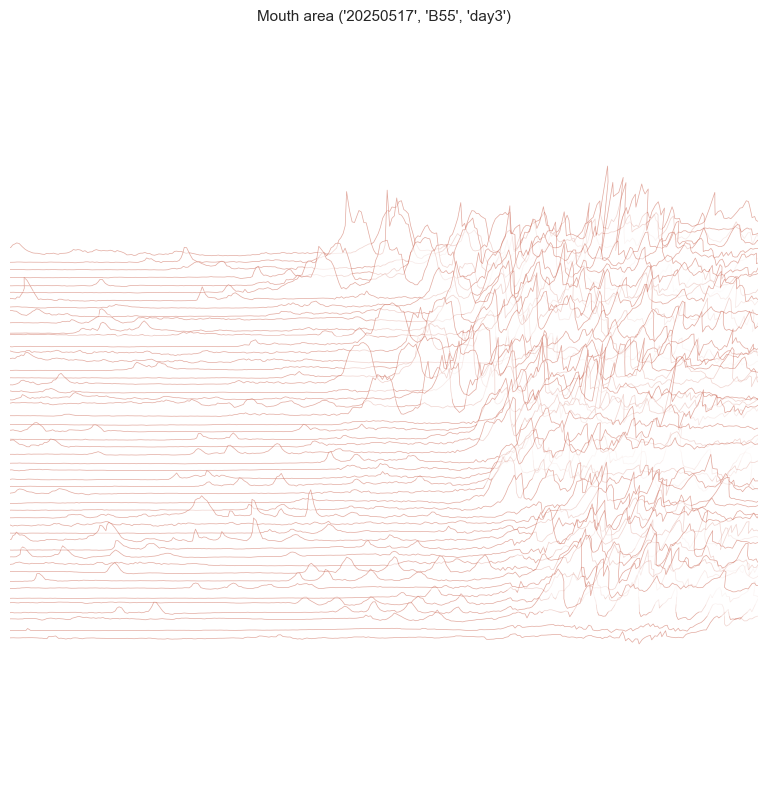

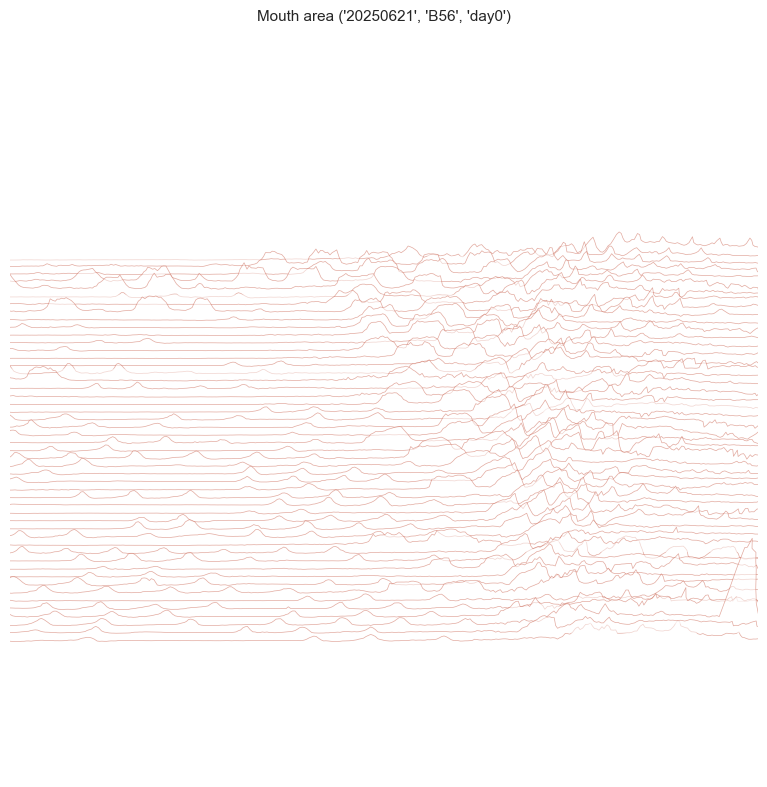

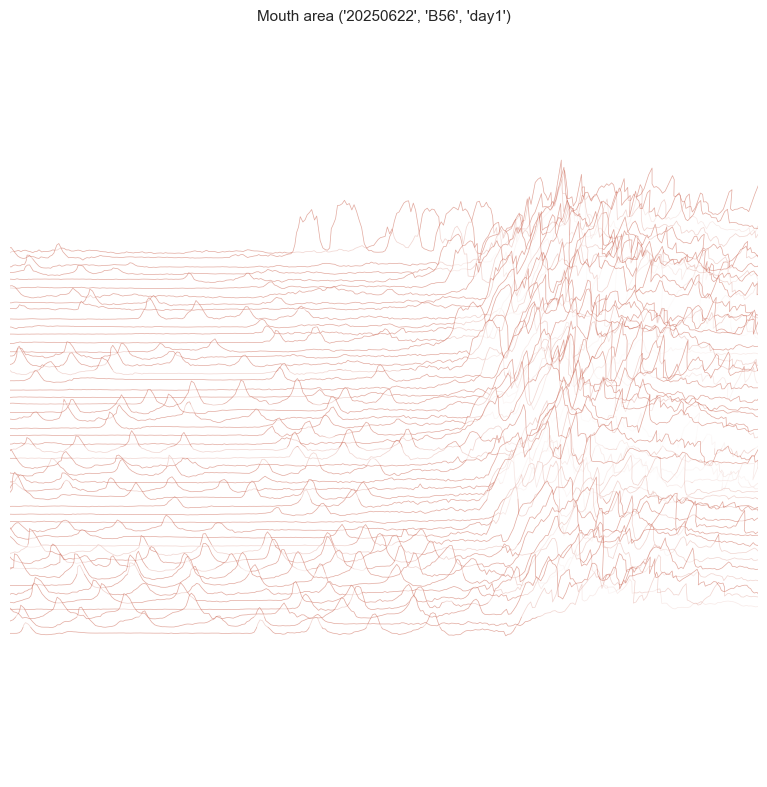

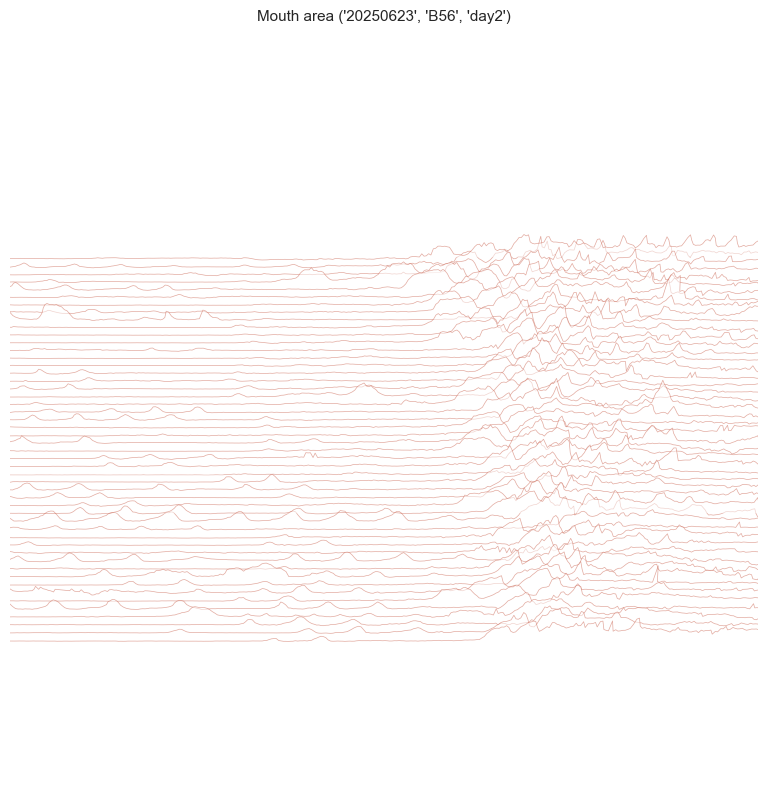

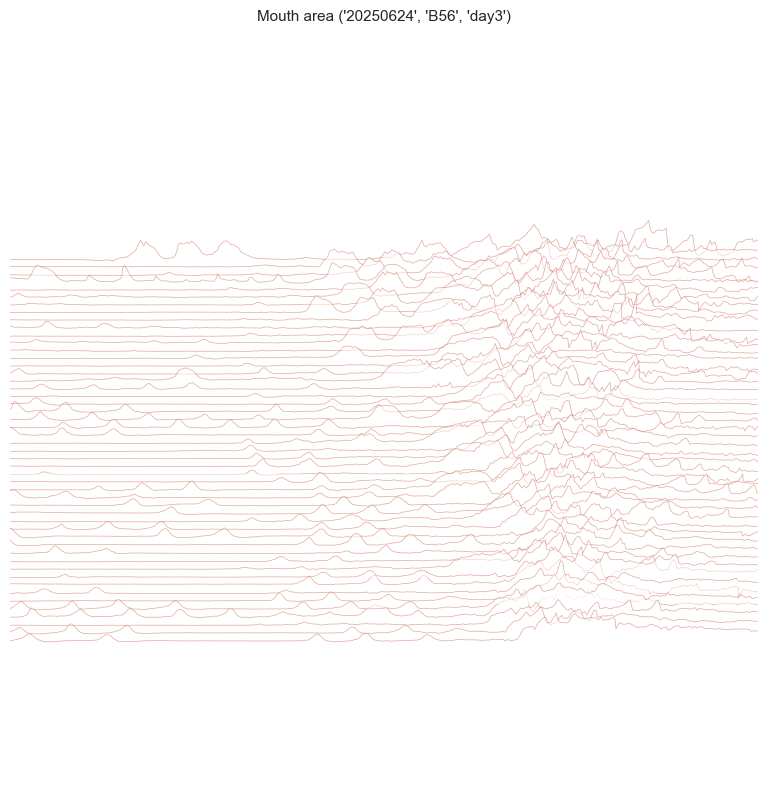

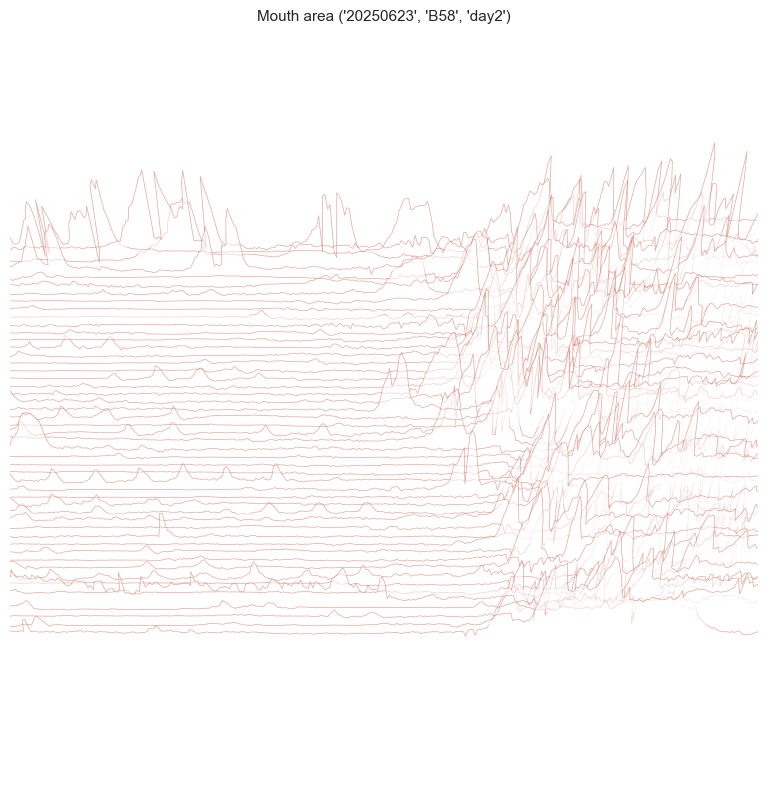

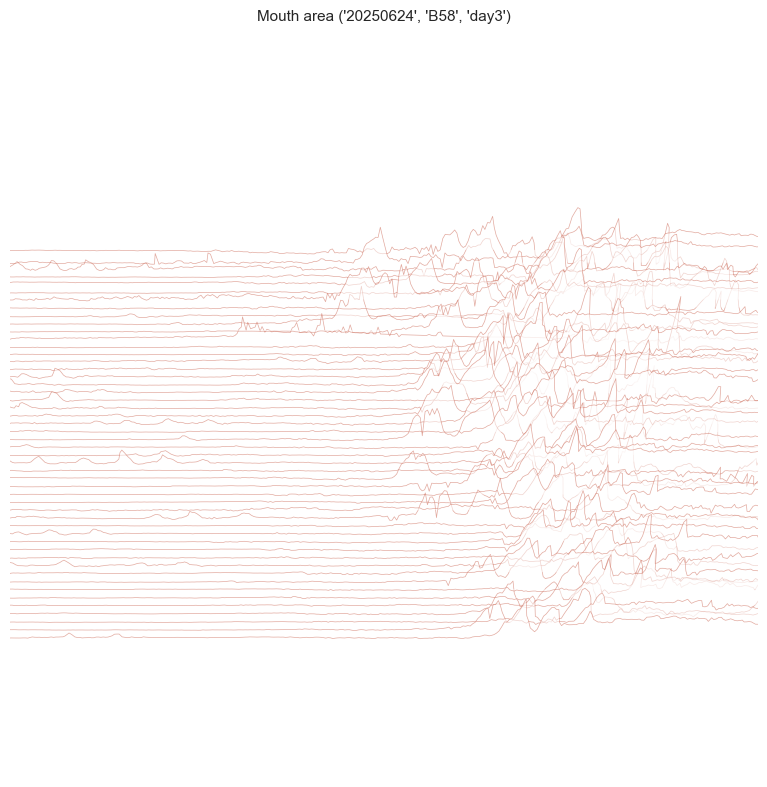

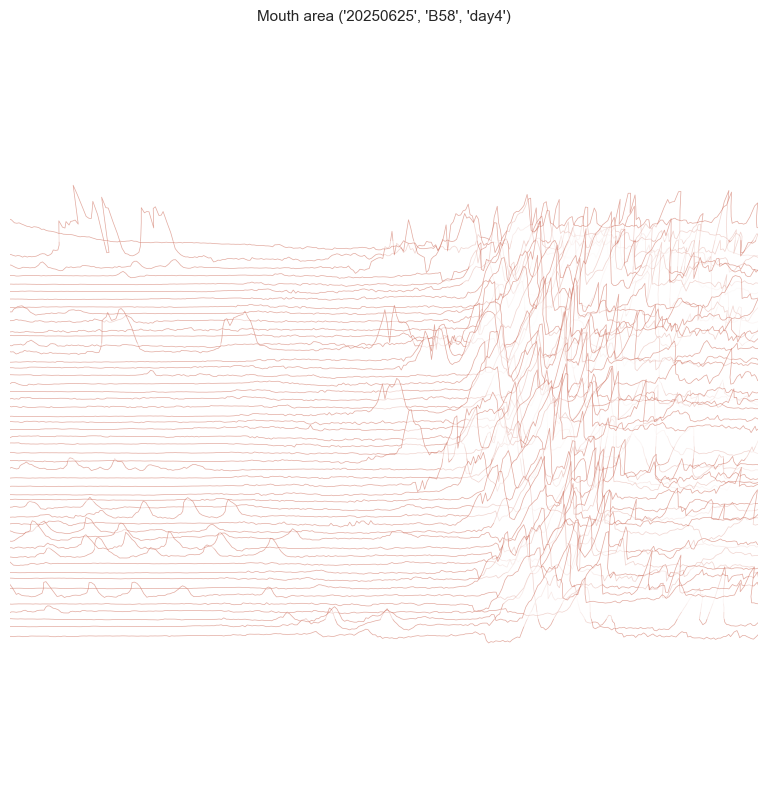

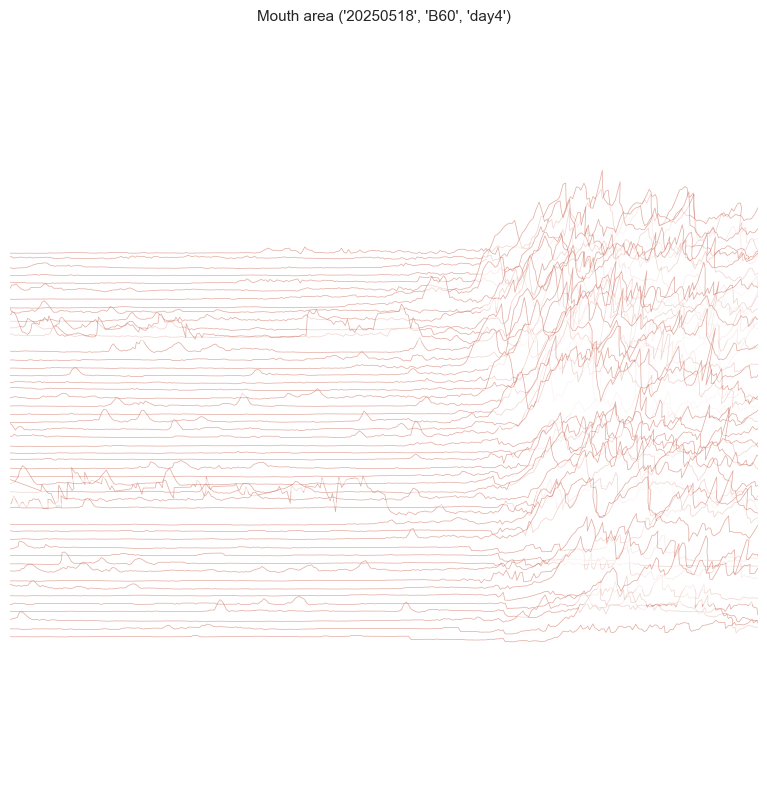

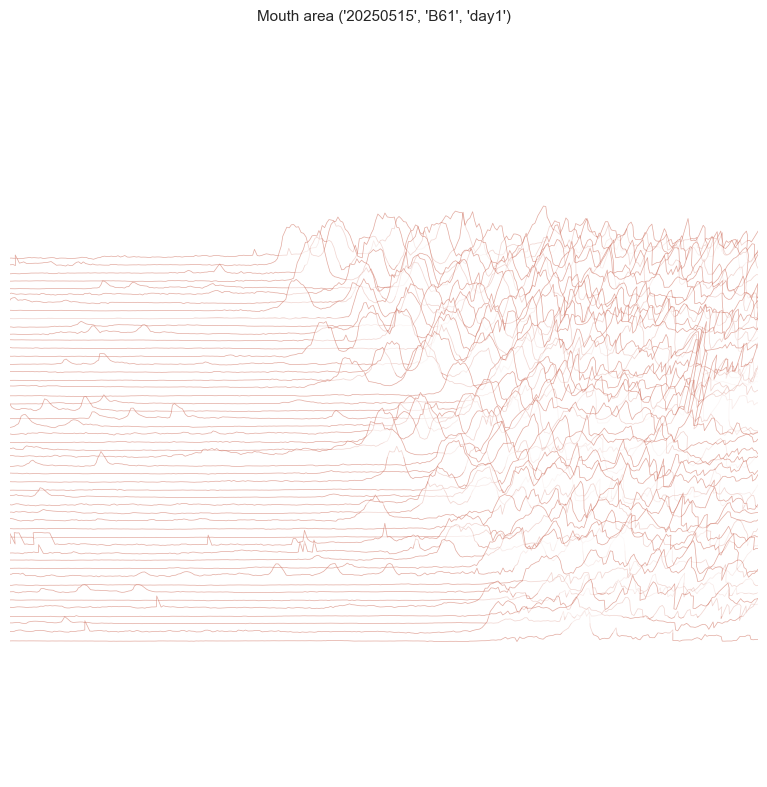

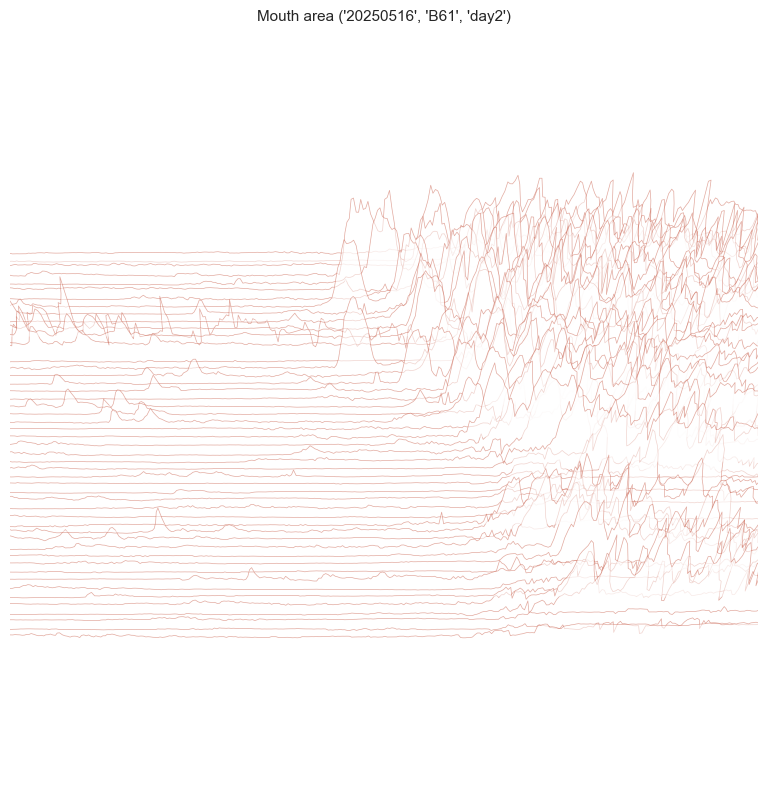

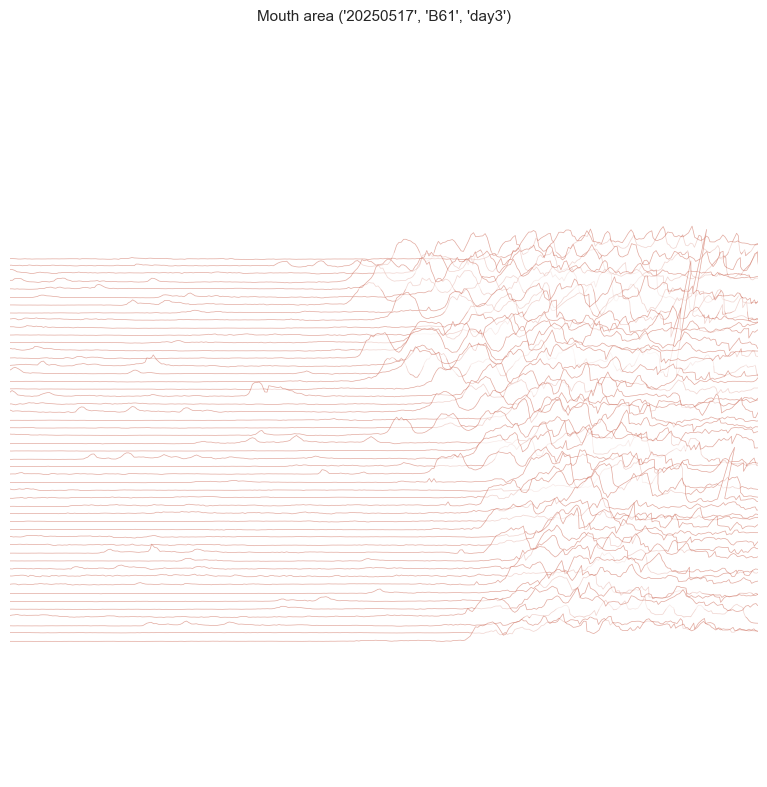

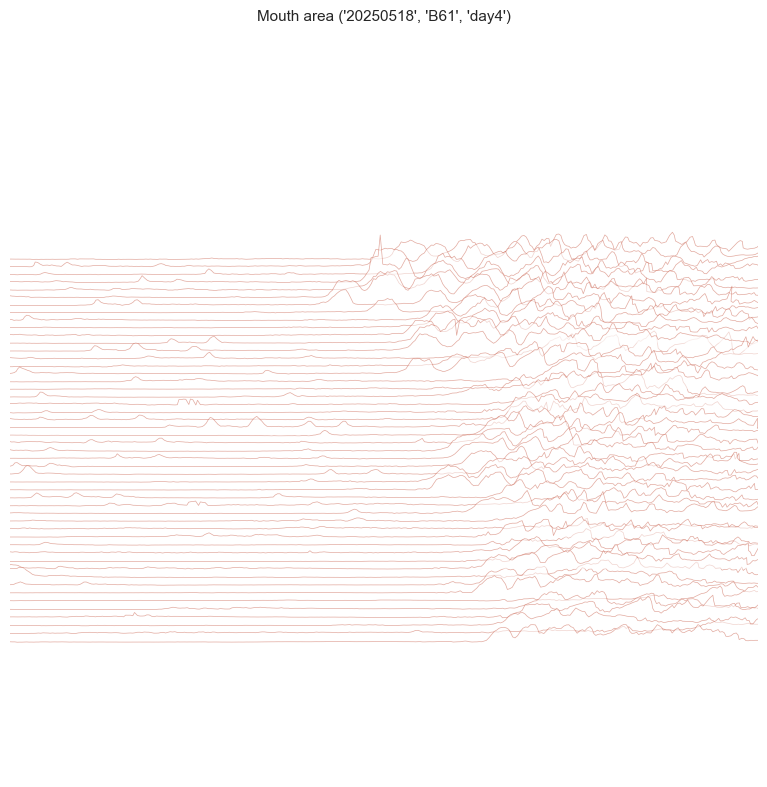

In [17]:
import matplotlib.collections as mc
from mpl_toolkits.mplot3d import Axes3D

for example_dmc in satiation_study.keys():

    mouth_example = meas_df.query("date == @example_dmc[0] & "
                                  "mouse == @example_dmc[1] & "
                                  "condition == @example_dmc[2] & "
                                  "measurement_name == 'mouth-area'")["raw_timeseries"].values[0]
    
    # Define the number of traces and data points per trace
    total_trials = len(base_trials[example_dmc]) #50 # Number of trials
    n_timepoints = len(base_trials[example_dmc][0])  # Number of data points
    time_range = np.linspace(-OFFSET/100, ITI, n_timepoints) # Time

    n_trials = base_trials[example_dmc] # trials timeseries
    trial_count = 0

    # Create the 3D-like plot using PolyCollection
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Create polygons for each trial
    polygons = []
    colors = []
    zs = []

    for i, trial in enumerate(n_trials): #iterate over trials
        date = int(example_dmc[0])
        success = pellet_table.query("Date == @date & "
                                    "Mouse == @example_dmc[1] & "
                                    "Cond == @example_dmc[2]")[f"Pellet {i + 1}"].values[0]
        # Get the data for this trial
        if success != -1:
            area = mouth_example[trial] #mouth_example[f"Trial {i}"][0]
            
            # Define vertices for the polygon (time vs mouth area amplitude)
            vertices = [] 
            
            # Add all the data points
            for ts, amp in zip(time_range, area):
                vertices.append((ts, amp))
            
            
            polygons.append(vertices)
            zs.append(trial_count)
            trial_count += 1
            colors.append([1,1,1, 0.5]) #White filling with some transparency (alpha = 0.5)

    # Create the PolyCollection
    poly_collection = mc.PolyCollection(
        polygons,
        facecolors=colors,
        edgecolors=MEASUREMENT_CMAP["mouth-area"],
        closed = False,
        alpha=0.5,
        linewidths=0.5
    )

    # poly_collection

    # Add the collection to the 3D plot
    ax.add_collection3d(poly_collection, zs=zs[::-1], zdir='y')

    # Set the limits and labels
    # ax.set_xlim(-5, 30)
    ax.set_xlim(0, 2) # Plot only the first 2 seconds
    # ax.set_ylim(0, n_trials)
    # ax.set_yticklabels(np.arange(0,51,10)[::-1])
    # ax.set_zlim(0, 3.5)

    ax.set_xlabel('Time (sec)')
    ax.set_ylabel('Trial #')
    ax.set_zlabel('Area')
    ax.set_title(f'Mouth area {example_dmc}')

    # Adjust the viewing angle
    # ax.view_init(elev=20, azim=-135)
    # ax.view_init(elev=60, azim=-90)
    ax.view_init(elev=70, azim=-90)
    ax.axis("off")

    plt.tight_layout()
    plt.show()

    # save_figure()
    # plt.savefig(f"rev_figs/chew/50chew/50chew-{example_dmc[1]}-{example_dmc[0]}")

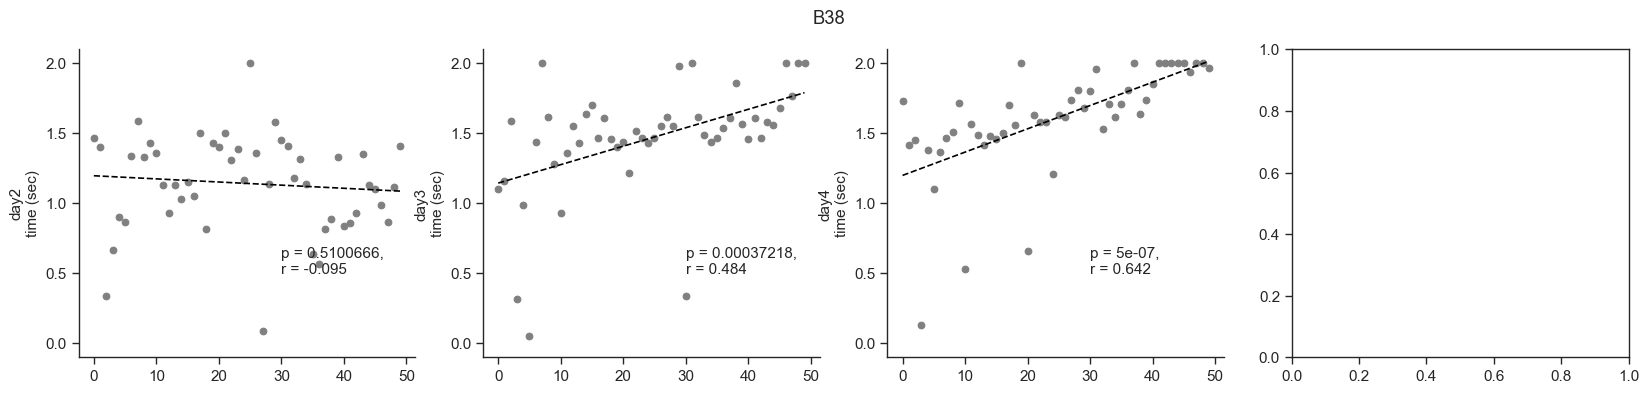

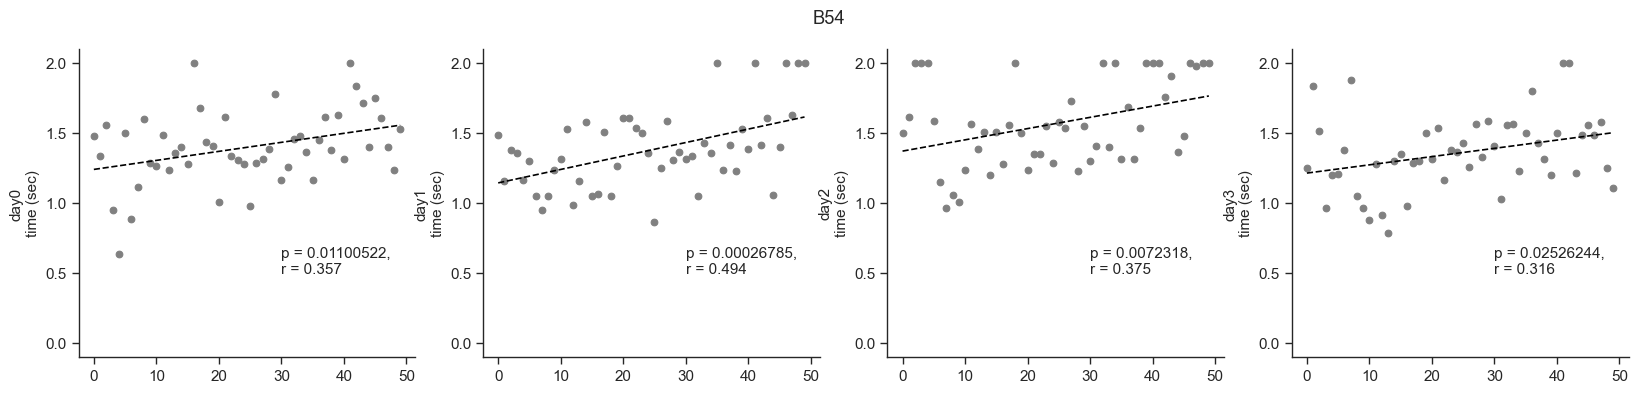

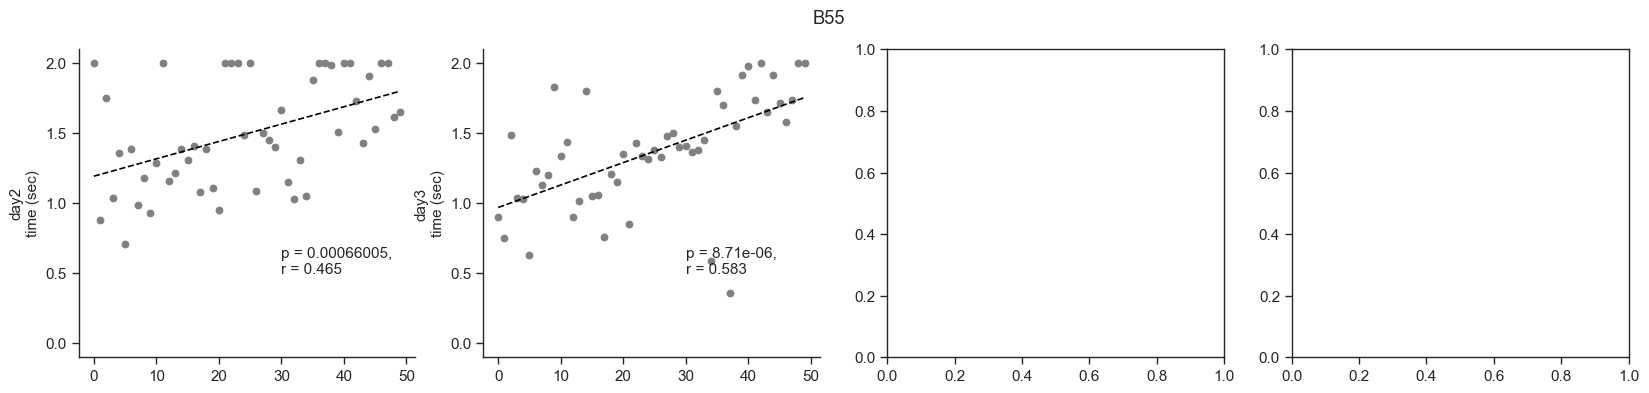

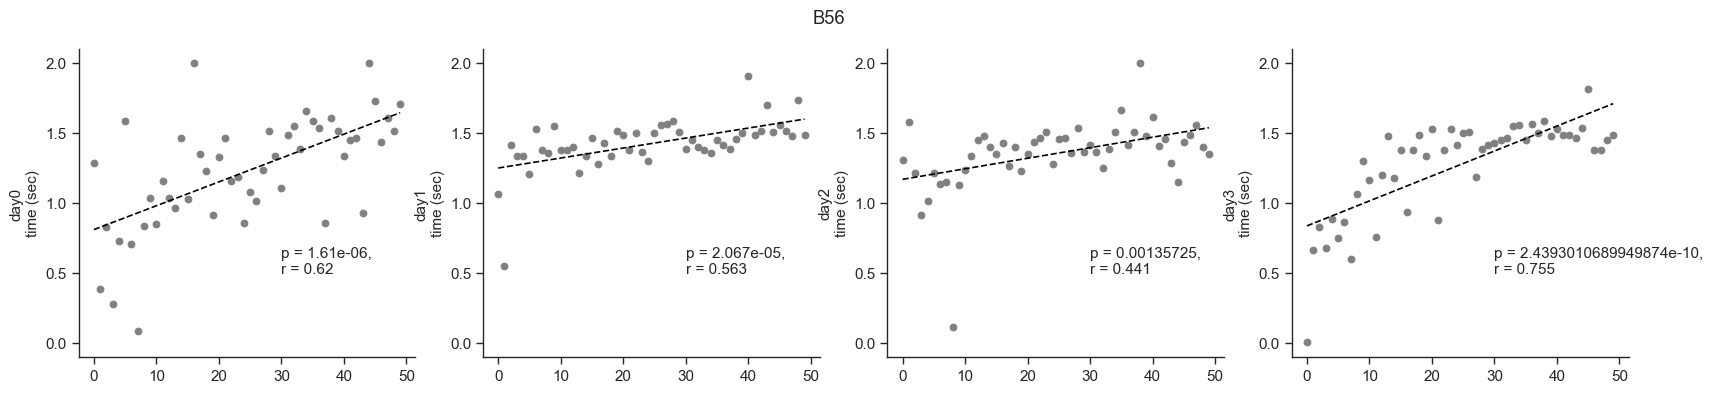

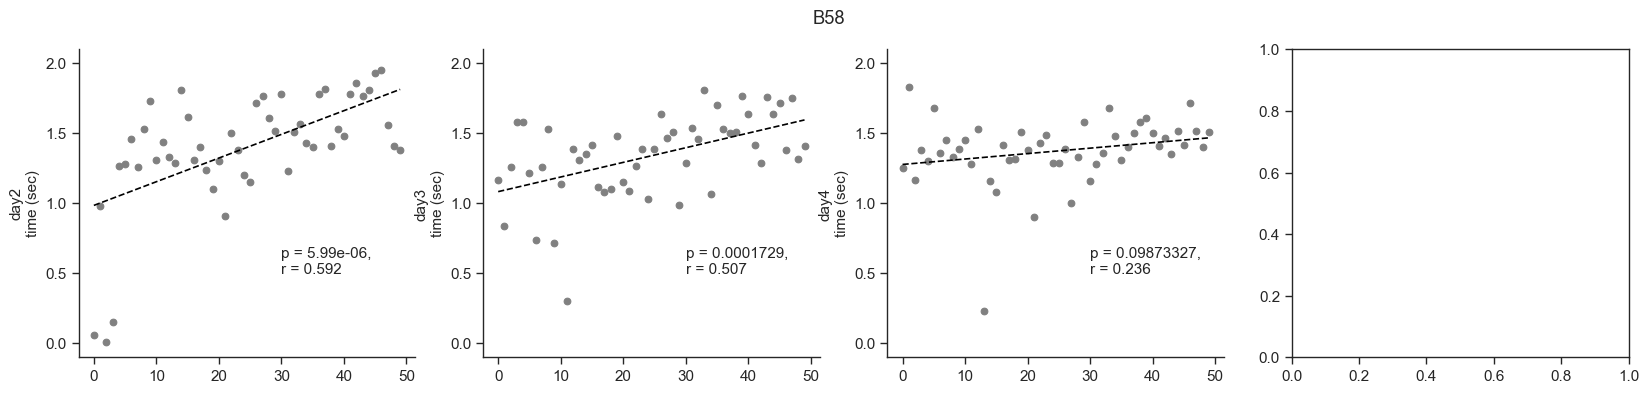

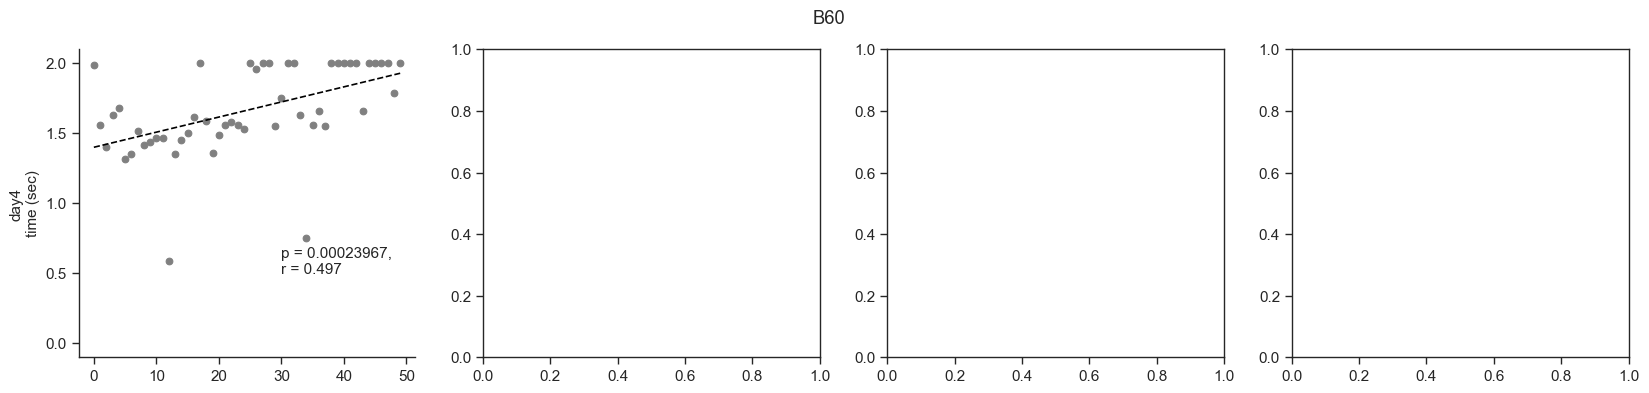

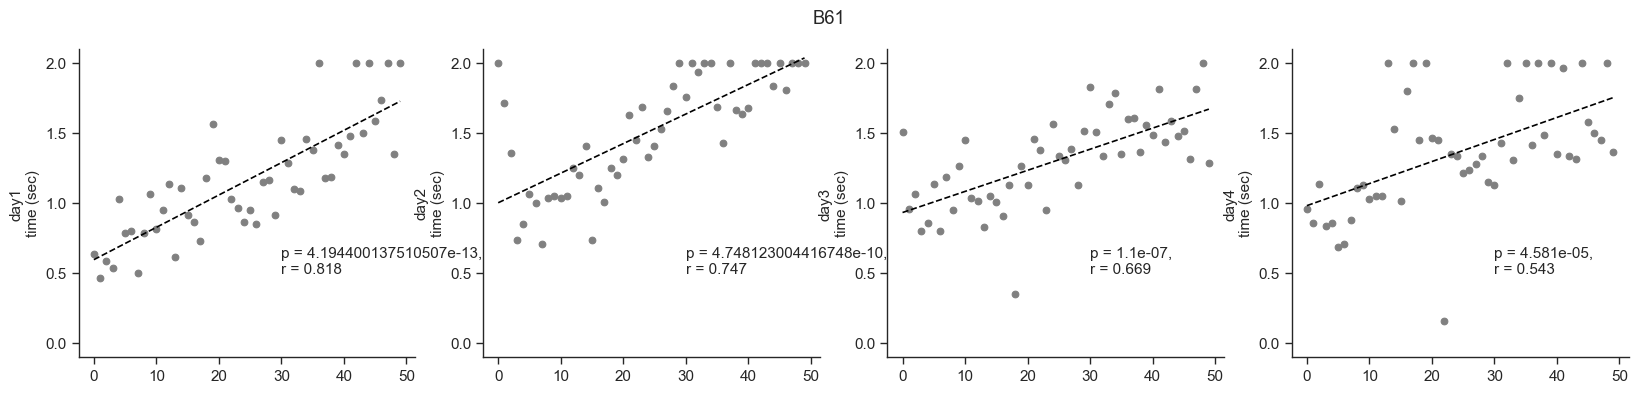

In [18]:
current_mouse = list(satiation_study.keys())[0][1]
day_total = sum(1 for _dmc in satiation_study if _dmc[1] == current_mouse)
fig, axs = plt.subplots(1, 4, figsize=(5 * 4, 4)) #4 is max n of days, this allows same dims for all mice
fig.suptitle(current_mouse)
sday = 0
m_dict = {}
n_dict = {}
lin_fits = {}

for dmc in satiation_study.keys():
    if dmc[1] != current_mouse:
        # save_figure("rev_figs/chew/1bite/",f"1st-peak-{current_mouse}",fig, formats = ["svg"])
        current_mouse = dmc[1]
        day_total = sum(1 for _dmc in satiation_study.keys() if _dmc[1] == current_mouse)
        fig, axs = plt.subplots(1, 4, figsize=(5 * 4, 4)) 
        fig.suptitle(current_mouse)
        trial_n = 0
        sday = 0
    # Linear regression
    xs = np.arange(0, len(first_peak_dict[dmc]))
    ys = (np.array(first_peak_dict[dmc]) - OFFSET) / FPS
    m, n, r_val, p_val, std_err = linregress(xs, ys) # m = slope, n = intercept
    ysh = m * xs + n
    m_dict[dmc] = m
    n_dict[dmc] = n
    lin_fits[dmc] = ysh

    axs[sday].scatter(xs, ys, color = 'gray')
    axs[sday].plot(xs, ysh, linestyle = '--', color = 'black')
    axs[sday].set(ylim = (-0.1, 2.1), ylabel = f"{dmc[2]}\ntime (sec)")
    axs[sday].yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    axs[sday].spines[['top', 'right']].set_visible(False)
    axs[sday].text(30, 0.5, f'p = {round(p_val,8) if p_val > 1e-8 else p_val},\nr = {round(r_val,3)}')
    
    sday += 1
# save_figure("rev_figs/chew/1bite/",f"1st-peak-{current_mouse}", fig, formats = ["svg"])

## Panel B

Text(30, 0.5, 'p = 6.987951353336019e-25,\nr = 0.94468')

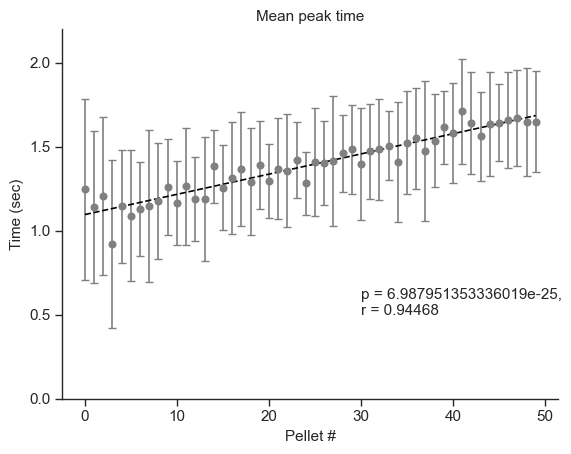

In [19]:
# Mean first peak time per pellet 
fig, ax = plt.subplots(1,1)

# Compute mean and standard deviation
first_peak_mean = np.mean([(np.array(first_peak_dict[dmc]) - OFFSET)/FPS for dmc in satiation_study.keys()], axis=0)
first_peak_sd = np.std([(np.array(first_peak_dict[dmc]) - OFFSET)/FPS for dmc in satiation_study.keys()], axis=0, ddof=1)
xs = np.arange(0, len(first_peak_mean))

# Plot it
plt.errorbar(xs, first_peak_mean, yerr=first_peak_sd, fmt='o', capsize=3, color = 'gray')

# Fit a line to the mean values
m, n, r_val, p_val, std_err = linregress(xs, first_peak_mean) # m = slope, n = intercept
ysh = m * xs + n
plt.plot(xs, ysh, linestyle='dashed', color='black')

# Line using mean m and n from all the fitted lines - not necessarily the same, but the same in this case
# m_mean = np.mean(list(m_dict.values()))
# n_mean = np.mean(list(n_dict.values()))
# y_mean = m_mean * xs + n_mean 
# plt.plot(xs, y_mean, linestyle='dashed', color='blue')

# Plot it
ax.spines[['top', 'right']].set_visible(False)
ax.set(title='Mean peak time', ylabel='Time (sec)', xlabel = 'Pellet #',
       ylim = (0,2.2), yticks = [0, 0.5, 1, 1.5, 2])
ax.text(30, 0.5, f'p = {p_val},\nr = {round(r_val,6)}')
# save_figure("rev_figs/chew/", "mean-slopes", fig, formats = ["svg"])